<a href="https://colab.research.google.com/github/yeyevtushenko/NLP_YevtushenkoBS-25/blob/main/NLP_%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%969_%D0%84%D0%B2%D1%82%D1%83%D1%88%D0%B5%D0%BD%D0%BA%D0%BE_%D0%91%D0%A1_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Пратична робота №9

##Реалізуйте модель наведену у прикладі. Завантажте дані рецептурного набору NYT Ingredients Dataset. Візуалізуйте кілька прикладів рецептів із тегами за допомогою show_markup. Проведіть тренування моделі. Протестуйте модель на відкладеній вибірці рецептів. Для кожного рецепту порівняйте істинні теги та передбачені теги.

In [2]:
!pip install ipymarkup

In [7]:
import warnings
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

from collections import Counter
from ipymarkup import show_box_markup
from ipymarkup.palette import PALETTE, BLUE, RED, GREEN, PURPLE, BROWN, ORANGE

torch.manual_seed(1)
warnings.filterwarnings('ignore')

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DEVICE: cuda
GPU: Tesla T4


   index                                              input              name  \
0      0  1 1/4 cups cooked and pureed fresh butternut s...  butternut squash   
1      1  1 cup peeled and cooked fresh chestnuts (about...         chestnuts   
2      2            1 medium-size onion, peeled and chopped             onion   
3      3                    2 stalks celery, chopped coarse            celery   
4      4                    1 1/2 tablespoons vegetable oil     vegetable oil   

    qty  range_end        unit  \
0  1.25        0.0         cup   
1  1.00        0.0         cup   
2  1.00        0.0         NaN   
3  2.00        0.0       stalk   
4  1.50        0.0  tablespoon   

                                             comment  
0  cooked and pureed fresh, or 1 10-ounce package...  
1  peeled and cooked fresh (about 20), or 1 cup c...  
2                    medium-size, peeled and chopped  
3                                     chopped coarse  
4                                


tensor([  57, 2245, 2133, 1520, 4060, 2650, 1846, 4624,   25, 3729,   42,  125,
        3771, 2668, 4624,   25, 2303])
tensor([3, 5, 0, 6, 6, 6, 2, 7, 9, 6, 6, 6, 6, 6, 2, 9, 6])



Розмір train: 40000
Розмір test: 9848
LSTMTagger(
  (word_embeddings): Embedding(5194, 32)
  (lstm): LSTM(32, 32)
  (hidden2tag): Linear(in_features=32, out_features=10, bias=True)
)
cuda:0
Epoch 1, Step 0, Loss: 2.3418405055999756
Epoch 1, Step 500, Loss: 0.3019073009490967
Epoch 1, Step 1000, Loss: 1.7314529418945312
Epoch 1, Step 1500, Loss: 1.2097339630126953
Epoch 1, Step 2000, Loss: 1.692588210105896
Epoch 1, Step 2500, Loss: 0.24061132967472076
Epoch 1, Step 3000, Loss: 0.13046318292617798
Epoch 1, Step 3500, Loss: 0.3787206709384918
Epoch 1, Step 4000, Loss: 0.08534860610961914
Epoch 1, Step 4500, Loss: 3.6756582260131836
Epoch 1, Step 5000, Loss: 0.41510096192359924
Epoch 1, Step 5500, Loss: 1.0232568979263306
Epoch 1, Step 6000, Loss: 0.47065624594688416
Epoch 1, Step 6500, Loss: 0.04664229601621628
Epoch 1, Step 7000, Loss: 0.3436392545700073
Epoch 1, Step 7500, Loss: 0.3360738754272461
Epoch 1, Step 8000, Loss: 0.3114546239376068
Epoch 1, Step 8500, Loss: 0.0178015083074569

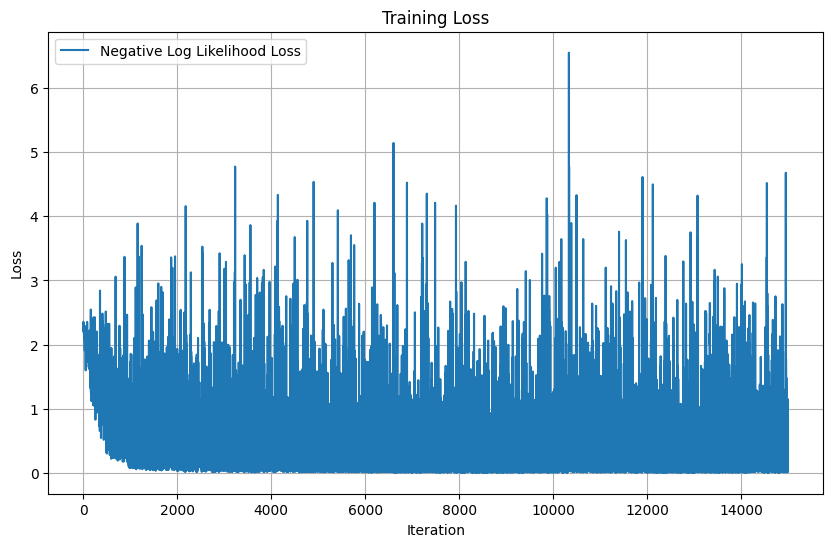

Істинні теги:
5 (B-QTY) cloves (B-UNIT) garlic (B-NAME) , (OTHER) peeled (B-COMMENT) and (I-COMMENT) lightly (I-COMMENT) crushed (I-COMMENT)
Передбачені теги:
5 (B-QTY) cloves (B-NAME) garlic (B-NAME) , (OTHER) peeled (B-COMMENT) and (I-COMMENT) lightly (I-COMMENT) crushed (I-COMMENT)

Істинні теги:
2 (B-QTY) teaspoons (B-UNIT) baking (B-NAME) soda (I-NAME)
Передбачені теги:
2 (B-QTY) teaspoons (B-UNIT) baking (B-NAME) soda (I-NAME)

Істинні теги:
1/2 (B-QTY) cup (B-UNIT) dry (B-NAME) white (I-NAME) wine (I-NAME)
Передбачені теги:
1/2 (B-QTY) cup (B-UNIT) dry (B-NAME) white (I-NAME) wine (I-NAME)

Істинні теги:
4 (B-QTY) cups (B-UNIT) chicken (B-NAME) stock (I-NAME)
Передбачені теги:
4 (B-QTY) cups (B-UNIT) chicken (B-NAME) stock (I-NAME)

Істинні теги:
12 (B-QTY) large (B-COMMENT) fresh (I-COMMENT) figs (B-NAME)
Передбачені теги:
12 (B-QTY) large (B-COMMENT) fresh (I-COMMENT) figs (B-NAME)

Істинні теги:
1/4 (B-QTY) cup (B-UNIT) vegetable (B-NAME) oil (I-NAME)
Передбачені теги:
1/4 (B

In [6]:
PALETTE.set('NAME', BLUE)
PALETTE.set('UNIT', RED)
PALETTE.set('QTY', GREEN)
PALETTE.set('RANGE_END', GREEN)
PALETTE.set('INDEX', PURPLE)
PALETTE.set('COMMENT', ORANGE)
PALETTE.set('OTHER', BROWN)

class Converter():
    def __init__(self, vocabulary, tags):
        self.idx_to_word = sorted(vocabulary)
        self.idx_to_tag = sorted(tags)
        self.word_to_idx = {word: idx for idx, word in enumerate(self.idx_to_word)}
        self.tag_to_idx = {tag: idx for idx, tag in enumerate(self.idx_to_tag)}

    def words_to_index(self, words):
        return torch.tensor([self.word_to_idx[w] for w in words], dtype=torch.long)

    def tags_to_index(self, words):
        return torch.tensor([self.tag_to_idx[w] for w in words], dtype=torch.long)

    def indices_to_words(self, indices):
        if torch.is_tensor(indices):
            indices = indices.detach().cpu().tolist()
        return [self.idx_to_word[i] for i in indices]

    def indices_to_tags(self, indices):
        if torch.is_tensor(indices):
            indices = indices.detach().cpu().tolist()
        return [self.idx_to_tag[i] for i in indices]

def prepare_data(lines):
    recipes_w_tags = []
    recipe, tags = [], []

    for line in lines:
        if len(line) > 0:
            word, label = line.split('\t')
            recipe.append(word)
            tags.append(label)
        else:
            if len(recipe) > 0:
                recipes_w_tags.append((recipe, tags))
            recipe, tags = [], []

    if len(recipe) > 0:
        recipes_w_tags.append((recipe, tags))

    return recipes_w_tags

def show_markup(recipe, tags):
    mapper = lambda tag: tag[2:] if tag != 'OTHER' else tag
    tags = [mapper(tag) for tag in tags]

    text = ' '.join(recipe)
    spans = []

    start, end, tag = 0, len(recipe[0]), tags[0]

    for word, ttag in zip(recipe[1:], tags[1:]):
        if tag == ttag:
            end += 1 + len(word)
        else:
            spans.append((start, end, tag))
            start = end + 1
            end = start + len(word)
            tag = ttag

    spans.append((start, end, tag))
    show_box_markup(text, spans, palette=PALETTE)

def form_vocabulary_and_tagset(recipes):
    dictionary = set()
    labels = set()

    for line in recipes:
        if len(line) > 0:
            word, label = line.split('\t')
            dictionary.add(word)
            labels.add(label)

    return dictionary, labels

df = pd.read_csv('nyt-ingredients-snapshot-2015.csv')
print(df.head())

datafile = 'BIO_recipe_dataset.txt'
lines = open(datafile, encoding='utf-8').read().splitlines()

vocabulary, labels = form_vocabulary_and_tagset(lines)
recipes_w_tags = prepare_data(lines)

print("Кількість рецептів:", len(recipes_w_tags))
print("Кількість слів у словнику:", len(vocabulary))
print("Кількість тегів:", len(labels))
print("Теги:", sorted(labels))

for i in range(5):
    test_recipe, test_tags = recipes_w_tags[i]
    show_markup(test_recipe, test_tags)
    print()

converter = Converter(vocabulary, labels)

test_recipe, test_tags = recipes_w_tags[0]
encoded_recipe = converter.words_to_index(test_recipe)
encoded_tags = converter.tags_to_index(test_tags)

print(encoded_recipe)
print(encoded_tags)
print()

decoded_recipe = converter.indices_to_words(encoded_recipe)
decoded_tags = converter.indices_to_tags(encoded_tags)

show_markup(decoded_recipe, decoded_tags)

training_data = recipes_w_tags[:40000]
test_data = recipes_w_tags[40000:]

print("Розмір train:", len(training_data))
print("Розмір test:", len(test_data))

EMBEDDING_DIM = 32
HIDDEN_DIM = 32
VOCAB_SIZE = len(converter.word_to_idx)
TAGSET_SIZE = len(converter.tag_to_idx)

class LSTMTagger(nn.Module):
    def __init__(self, embedding_dim, hidden_dim, vocab_size, tagset_size):
        super(LSTMTagger, self).__init__()
        self.hidden_dim = hidden_dim
        self.word_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim)
        self.hidden2tag = nn.Linear(hidden_dim, tagset_size)

    def forward(self, words):
        embeds = self.word_embeddings(words)
        lstm_out, _ = self.lstm(embeds.view(len(words), 1, -1))
        tag_space = self.hidden2tag(lstm_out.view(len(words), -1))
        tag_scores = F.log_softmax(tag_space, dim=1)
        return tag_scores

    def predict_tags(self, words):
        self.eval()
        with torch.no_grad():
            tags_pred = self(words).detach().cpu().numpy()
            tags_pred = np.argmax(tags_pred, axis=1)
        return tags_pred

model = LSTMTagger(EMBEDDING_DIM, HIDDEN_DIM, VOCAB_SIZE, TAGSET_SIZE).to(DEVICE)
loss_function = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

print(model)
print(next(model.parameters()).device)

losses = []

for epoch in range(1):
    model.train()
    for i, (recipe, tags) in enumerate(training_data):
        model.zero_grad()

        encoded_recipe = converter.words_to_index(recipe).to(DEVICE)
        encoded_tags = converter.tags_to_index(tags).to(DEVICE)

        tag_scores = model(encoded_recipe)
        loss = loss_function(tag_scores, encoded_tags)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if i % 500 == 0:
            print(f"Epoch {epoch + 1}, Step {i}, Loss: {loss.item()}")

        if i == 15000:
            break

plt.figure(figsize=(10, 6))
plt.plot(losses, label="Negative Log Likelihood Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.grid()
plt.show()

def predict_tags(model, converter, recipe):
    encoded_recipe = converter.words_to_index(recipe).to(DEVICE)
    encoded_tags = model.predict_tags(encoded_recipe)
    decoded_tags = converter.indices_to_tags(encoded_tags)
    return decoded_tags

def show_markup_pycharms(recipe, tags):
    result = []
    for word, tag in zip(recipe, tags):
        result.append(f"{word} ({tag})")
    print(" ".join(result))

for i in range(10):
    recipe, tags = test_data[np.random.randint(0, len(test_data))]
    tags_pred = predict_tags(model, converter, recipe)

    print("Істинні теги:")
    show_markup_pycharms(recipe, tags)

    print("Передбачені теги:")
    show_markup_pycharms(recipe, tags_pred)
    print()

def tag_statistics(model, converter, data):
    def tag_counter(predicted, ground):
        correct_tags = Counter()
        ground_tags = Counter(ground)

        for tag_p, tag_g in zip(predicted, ground):
            if tag_p == tag_g:
                correct_tags[tag_g] += 1

        return correct_tags, ground_tags

    total_correct, total_tags = Counter(), Counter()

    for recipe, tags in data:
        tags_pred = predict_tags(model, converter, recipe)
        tags_correct, tags_num = tag_counter(tags_pred, tags)
        total_correct.update(tags_correct)
        total_tags.update(tags_num)

    return total_correct, total_tags

total_correct, total_tags = tag_statistics(model, converter, test_data)

print('Статистика вірно передбачених тегів:\n')

tag_scores = []

for tag in total_tags.keys():
    acc = 100 * (total_correct[tag] / float(total_tags[tag]))
    tag_scores.append((tag, acc))

    print(f'для {tag}:')
    print(' вірно:\t', total_correct[tag])
    print(' всього:\t', total_tags[tag])
    print('% вірно:\t', acc)
    print()

print('----------')
print('загалом:')
print(' вірно:\t', sum(total_correct.values()))
print(' всього:\t', sum(total_tags.values()))
print('% вірно:\t', 100 * (sum(total_correct.values()) / sum(total_tags.values())))

tag_scores = sorted(tag_scores, key=lambda x: x[1], reverse=True)

print("\nНайкраще передбачувані теги:")
for tag, acc in tag_scores[:3]:
    print(f"{tag}: {acc:.2f}%")

print("\nНайгірше передбачувані теги:")
for tag, acc in tag_scores[-3:]:
    print(f"{tag}: {acc:.2f}%")

###Оцініть, які теги модель передбачає найкраще, а які найгірше.

Було реалізовано модель LSTMTagger та проведено навчання на наборі даних NYT Ingredients Dataset. Після цього модель протестовано на відкладеній вибірці та виконано порівняння істинних і передбачених тегів. Результати показали, що модель добре визначає кількість та одиниці вимірювання, а також досить точно розпізнає назви інгредієнтів. У більшості прикладів передбачені теги збігаються з істинними, хоча іноді виникають помилки у визначенні ролі окремих слів. Найкраще модель передбачає теги B-QTY, B-UNIT та I-COMMENT. Найгірші результати спостерігаються для тегів OTHER, B-COMMENT та B-RANGE_END.
Загальна точність моделі становить близько 84%, що свідчить про достатньо хорошу якість.

##Підрахуйте кількість правильних передбачень для кожного тегу та загальну точність моделі. Побудуйте матрицю помилок для тегів. Нормалізовану матрицю помилок у відсотках.

Загальна точність: 84.42403892277119

Статистика по тегах:
B-COMMENT: 5367 / 7824 (68.60%)
B-NAME: 8728 / 10279 (84.91%)
B-QTY: 8267 / 8421 (98.17%)
B-RANGE_END: 113 / 156 (72.44%)
B-UNIT: 6788 / 7075 (95.94%)
I-COMMENT: 13717 / 14988 (91.52%)
I-NAME: 4336 / 5528 (78.44%)
OTHER: 1964 / 4101 (47.89%)


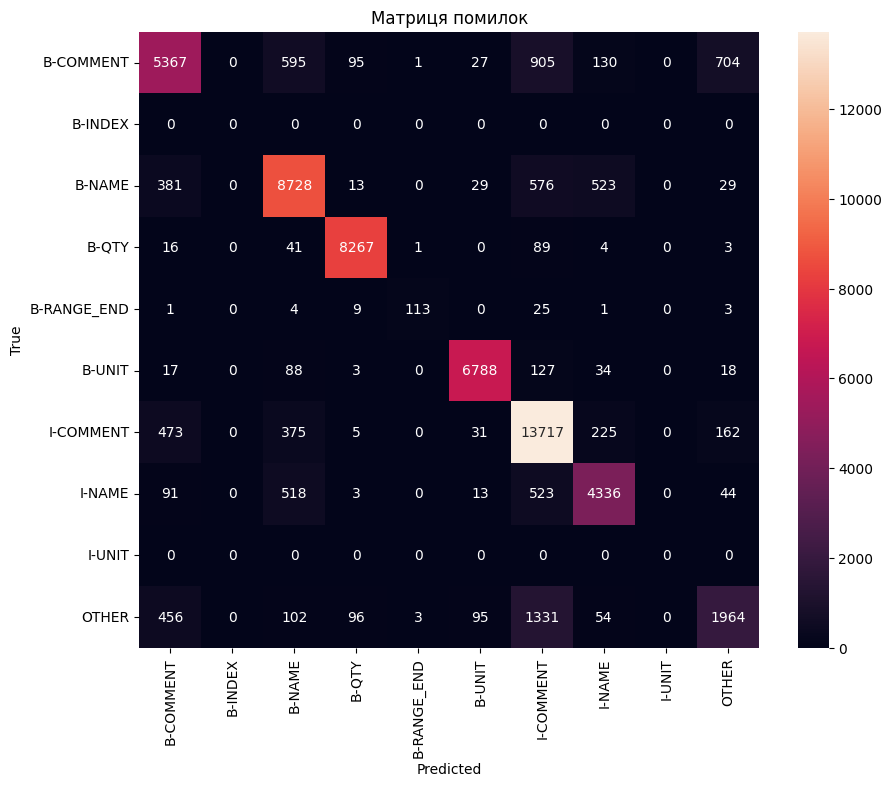

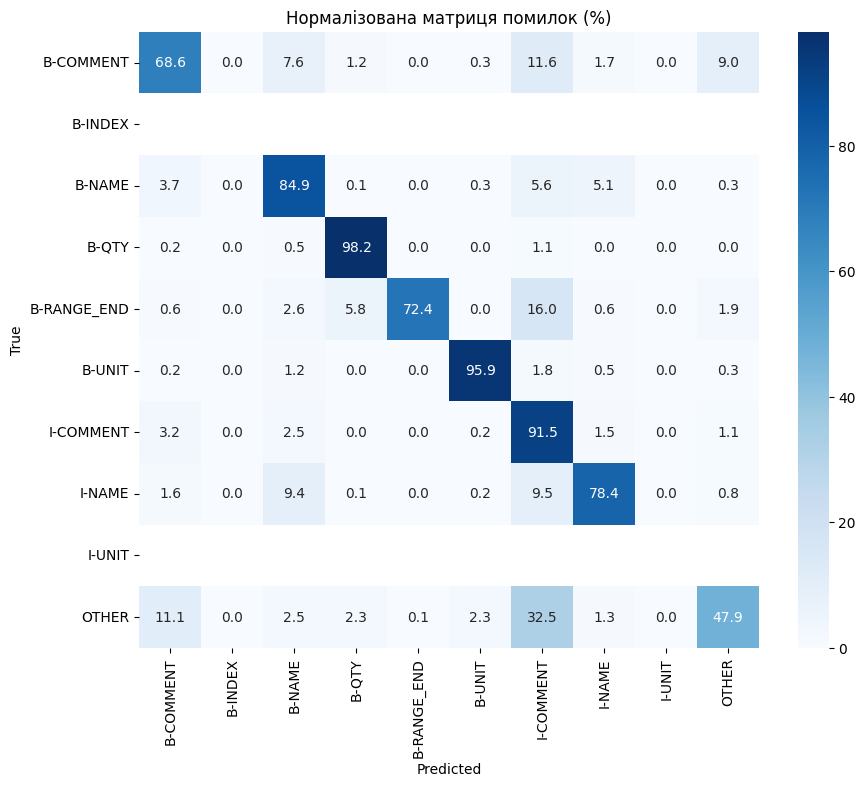

In [8]:
def collect_predictions(model, converter, data):
    y_true = []
    y_pred = []

    for recipe, tags in data:
        encoded_recipe = converter.words_to_index(recipe).to(DEVICE)

        with torch.no_grad():
            pred = model(encoded_recipe)
            pred = pred.argmax(dim=1).cpu().numpy()

        true = converter.tags_to_index(tags).cpu().numpy()

        y_true.extend(true)
        y_pred.extend(pred)

    return np.array(y_true), np.array(y_pred)

y_true, y_pred = collect_predictions(model, converter, test_data)

labels_list = list(converter.tag_to_idx.keys())
labels_list_sorted = sorted(labels_list)
label_indices = [converter.tag_to_idx[label] for label in labels_list_sorted]

cm = confusion_matrix(y_true, y_pred, labels=label_indices)

accuracy = (y_true == y_pred).sum() / len(y_true)
print("Загальна точність:", accuracy * 100)

correct_per_tag = {}
total_per_tag = {}

for tag, idx in converter.tag_to_idx.items():
    mask = (y_true == idx)
    total = mask.sum()
    correct = ((y_true == idx) & (y_pred == idx)).sum()

    total_per_tag[tag] = total
    correct_per_tag[tag] = correct

print("\nСтатистика по тегах:")
for tag in sorted(converter.tag_to_idx.keys()):
    if total_per_tag[tag] > 0:
        acc = correct_per_tag[tag] / total_per_tag[tag] * 100
        print(f"{tag}: {correct_per_tag[tag]} / {total_per_tag[tag]} ({acc:.2f}%)")

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels_list_sorted,
            yticklabels=labels_list_sorted)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Матриця помилок")
plt.show()

cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.1f',
            xticklabels=labels_list_sorted,
            yticklabels=labels_list_sorted,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Нормалізована матриця помилок (%)")
plt.show()

##Покращення моделі: змініть параметри моделі – збільшіть розмір ембеддингів або прихованого шару LSTM, додайте Dropout для запобігання перенавчанню, повторіть навчання та оцініть, чи покращилася якість.

ImprovedLSTMTagger(
  (word_embeddings): Embedding(5194, 64)
  (dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(64, 64)
  (hidden2tag): Linear(in_features=64, out_features=10, bias=True)
)
cuda:0
Epoch 1, Step 0, Loss: 2.380925178527832
Epoch 1, Step 500, Loss: 0.22254590690135956
Epoch 1, Step 1000, Loss: 0.7143464088439941
Epoch 1, Step 1500, Loss: 1.0336880683898926
Epoch 1, Step 2000, Loss: 1.3122721910476685
Epoch 1, Step 2500, Loss: 0.47360658645629883
Epoch 1, Step 3000, Loss: 0.21259428560733795
Epoch 1, Step 3500, Loss: 0.6914294958114624
Epoch 1, Step 4000, Loss: 0.12535330653190613
Epoch 1, Step 4500, Loss: 3.679612398147583
Epoch 1, Step 5000, Loss: 0.6764709949493408
Epoch 1, Step 5500, Loss: 0.7494441270828247
Epoch 1, Step 6000, Loss: 0.8039276003837585
Epoch 1, Step 6500, Loss: 0.1411677896976471
Epoch 1, Step 7000, Loss: 0.9562615752220154
Epoch 1, Step 7500, Loss: 0.6112349629402161
Epoch 1, Step 8000, Loss: 0.3903640806674957
Epoch 1, Step 8500, Loss: 0.161838

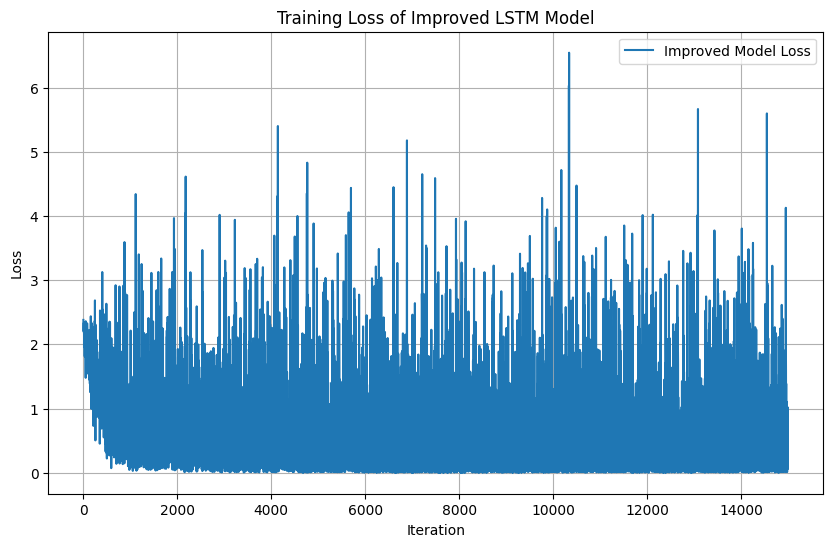

Істинні теги:
12 (B-QTY) thin (B-COMMENT) slices (I-COMMENT) Italian (I-COMMENT) bread (B-NAME) , (B-COMMENT) like (I-COMMENT) ciabata (I-COMMENT) or (I-COMMENT) Pugliese (I-COMMENT)
Передбачені теги:
12 (B-QTY) thin (B-NAME) slices (B-UNIT) Italian (B-NAME) bread (I-NAME) , (B-COMMENT) like (I-COMMENT) ciabata (I-COMMENT) or (I-COMMENT) Pugliese (I-COMMENT)

Істинні теги:
2 (B-QTY) tablespoons (B-UNIT) pitted (B-COMMENT) black (B-NAME) olives (I-NAME)
Передбачені теги:
2 (B-QTY) tablespoons (B-UNIT) pitted (B-COMMENT) black (I-NAME) olives (I-NAME)

Істинні теги:
2 (B-QTY) tablespoons (B-UNIT) minced (B-COMMENT) shallot (B-NAME)
Передбачені теги:
2 (B-QTY) tablespoons (B-UNIT) minced (B-COMMENT) shallot (B-NAME)

Істинні теги:
1 (B-QTY) pound (B-UNIT) salt (B-NAME) cod (I-NAME) or (B-COMMENT) stockfish (I-COMMENT)
Передбачені теги:
1 (B-QTY) pound (B-UNIT) salt (B-NAME) cod (I-NAME) or (B-COMMENT) stockfish (I-COMMENT)

Істинні теги:
1$1/2 (B-QTY) cups (B-UNIT) sugar (B-NAME)
Передбач

In [9]:
EMBEDDING_DIM = 64
HIDDEN_DIM = 64
DROPOUT = 0.3
VOCAB_SIZE = len(converter.word_to_idx)
TAGSET_SIZE = len(converter.tag_to_idx)

class ImprovedLSTMTagger(nn.Module):
    def __init__(self, embedding_dim, hidden_dim, vocab_size, tagset_size, dropout=0.3):
        super(ImprovedLSTMTagger, self).__init__()
        self.hidden_dim = hidden_dim
        self.word_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim)
        self.hidden2tag = nn.Linear(hidden_dim, tagset_size)

    def forward(self, words):
        embeds = self.word_embeddings(words)
        embeds = self.dropout(embeds)
        lstm_out, _ = self.lstm(embeds.view(len(words), 1, -1))
        lstm_out = self.dropout(lstm_out)
        tag_space = self.hidden2tag(lstm_out.view(len(words), -1))
        tag_scores = F.log_softmax(tag_space, dim=1)
        return tag_scores

    def predict_tags(self, words):
        self.eval()
        with torch.no_grad():
            tags_pred = self(words).detach().cpu().numpy()
            tags_pred = np.argmax(tags_pred, axis=1)
        return tags_pred

improved_model = ImprovedLSTMTagger(
    EMBEDDING_DIM,
    HIDDEN_DIM,
    VOCAB_SIZE,
    TAGSET_SIZE,
    dropout=DROPOUT
).to(DEVICE)

loss_function = nn.NLLLoss()
optimizer = optim.SGD(improved_model.parameters(), lr=0.1)

print(improved_model)
print(next(improved_model.parameters()).device)

improved_losses = []

for epoch in range(1):
    improved_model.train()
    for i, (recipe, tags) in enumerate(training_data):
        improved_model.zero_grad()

        encoded_recipe = converter.words_to_index(recipe).to(DEVICE)
        encoded_tags = converter.tags_to_index(tags).to(DEVICE)

        tag_scores = improved_model(encoded_recipe)
        loss = loss_function(tag_scores, encoded_tags)
        loss.backward()
        optimizer.step()

        improved_losses.append(loss.item())

        if i % 500 == 0:
            print(f"Epoch {epoch + 1}, Step {i}, Loss: {loss.item()}")

        if i == 15000:
            break

plt.figure(figsize=(10, 6))
plt.plot(improved_losses, label="Improved Model Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss of Improved LSTM Model")
plt.legend()
plt.grid()
plt.show()

def predict_tags_improved(model, converter, recipe):
    encoded_recipe = converter.words_to_index(recipe).to(DEVICE)
    encoded_tags = model.predict_tags(encoded_recipe)
    decoded_tags = converter.indices_to_tags(encoded_tags)
    return decoded_tags

for i in range(10):
    recipe, tags = test_data[np.random.randint(0, len(test_data))]
    tags_pred = predict_tags_improved(improved_model, converter, recipe)

    print("Істинні теги:")
    show_markup_pycharms(recipe, tags)

    print("Передбачені теги:")
    show_markup_pycharms(recipe, tags_pred)
    print()

def tag_statistics_improved(model, converter, data):
    def tag_counter(predicted, ground):
        correct_tags = Counter()
        ground_tags = Counter(ground)

        for tag_p, tag_g in zip(predicted, ground):
            if tag_p == tag_g:
                correct_tags[tag_g] += 1

        return correct_tags, ground_tags

    total_correct, total_tags = Counter(), Counter()

    for recipe, tags in data:
        tags_pred = predict_tags_improved(model, converter, recipe)
        tags_correct, tags_num = tag_counter(tags_pred, tags)
        total_correct.update(tags_correct)
        total_tags.update(tags_num)

    return total_correct, total_tags

total_correct_improved, total_tags_improved = tag_statistics_improved(improved_model, converter, test_data)

print('Статистика покращеної моделі:\n')

tag_scores_improved = []

for tag in total_tags_improved.keys():
    acc = 100 * (total_correct_improved[tag] / float(total_tags_improved[tag]))
    tag_scores_improved.append((tag, acc))

    print(f'для {tag}:')
    print(' вірно:\t', total_correct_improved[tag])
    print(' всього:\t', total_tags_improved[tag])
    print('% вірно:\t', acc)
    print()

overall_acc_improved = 100 * (sum(total_correct_improved.values()) / sum(total_tags_improved.values()))

print('----------')
print('загалом:')
print(' вірно:\t', sum(total_correct_improved.values()))
print(' всього:\t', sum(total_tags_improved.values()))
print('% вірно:\t', overall_acc_improved)

tag_scores_improved = sorted(tag_scores_improved, key=lambda x: x[1], reverse=True)

print("\nНайкраще передбачувані теги:")
for tag, acc in tag_scores_improved[:3]:
    print(f"{tag}: {acc:.2f}%")

print("\nНайгірше передбачувані теги:")
for tag, acc in tag_scores_improved[-3:]:
    print(f"{tag}: {acc:.2f}%")

Було покращено модель шляхом збільшення розміру ембеддингів і прихованого шару LSTM та додавання Dropout. Після повторного навчання модель знову протестовано на відкладеній вибірці. Отримані результати показали, що покращення не дало загального приросту якості. Загальна точність зменшилась з 84.42% до 83.78%. При цьому окремі теги модель почала визначати краще, зокрема B-QTY — 98.30%, B-UNIT — 96.61%, I-NAME — 80.77% та B-COMMENT — 71.33%. Водночас для частини тегів якість погіршилась. Найбільше зниження спостерігається для OTHER — 36.21% замість 47.89% та B-RANGE_END — 56.41% замість 72.44%. Також трохи знизилась точність для B-NAME та I-COMMENT. Отже, збільшення параметрів моделі та додавання Dropout не покращило загальну якість. Це означає, що для даної задачі така модифікація виявилась неефективною або потребує додаткового налаштування параметрів навчання.

##Розширення функціоналу – використовуйте Bidirectional LSTM замість звичайної LSTM.

BiLSTMTagger(
  (word_embeddings): Embedding(5194, 32)
  (lstm): LSTM(32, 32, bidirectional=True)
  (hidden2tag): Linear(in_features=64, out_features=10, bias=True)
)
cuda:0
Epoch 1, Step 0, Loss: 2.3493428230285645
Epoch 1, Step 500, Loss: 0.554191529750824
Epoch 1, Step 1000, Loss: 1.3953893184661865
Epoch 1, Step 1500, Loss: 0.9571050405502319
Epoch 1, Step 2000, Loss: 1.8096837997436523
Epoch 1, Step 2500, Loss: 0.26649996638298035
Epoch 1, Step 3000, Loss: 0.10147734731435776
Epoch 1, Step 3500, Loss: 0.48602598905563354
Epoch 1, Step 4000, Loss: 0.028434423729777336
Epoch 1, Step 4500, Loss: 3.113100051879883
Epoch 1, Step 5000, Loss: 0.47081509232521057
Epoch 1, Step 5500, Loss: 0.29163607954978943
Epoch 1, Step 6000, Loss: 0.31827735900878906
Epoch 1, Step 6500, Loss: 0.026283690705895424
Epoch 1, Step 7000, Loss: 0.5326454639434814
Epoch 1, Step 7500, Loss: 0.3161254823207855
Epoch 1, Step 8000, Loss: 0.3427157700061798
Epoch 1, Step 8500, Loss: 0.029705941677093506
Epoch 1, S

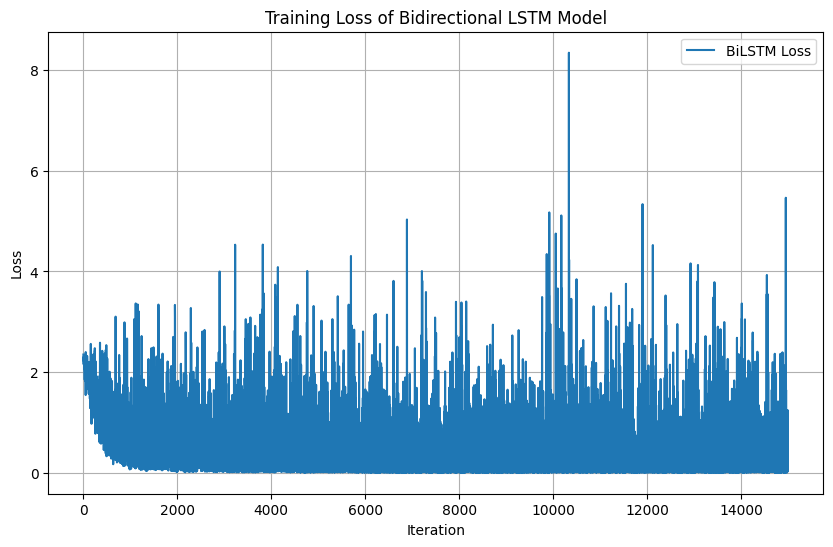

Істинні теги:
6 (B-QTY) tablespoons (B-UNIT) cold (B-COMMENT) butter (B-NAME)
Передбачені теги:
6 (B-QTY) tablespoons (B-UNIT) cold (B-COMMENT) butter (B-NAME)

Істинні теги:
2 (B-QTY) cloves (B-UNIT) garlic (B-NAME) , (OTHER) ground (B-COMMENT) to (I-COMMENT) a (OTHER) paste (I-COMMENT) with (I-COMMENT) a (OTHER) pinch (I-COMMENT) of (I-COMMENT) salt (I-COMMENT)
Передбачені теги:
2 (B-QTY) cloves (B-UNIT) garlic (B-NAME) , (OTHER) ground (B-COMMENT) to (I-COMMENT) a (I-COMMENT) paste (I-COMMENT) with (I-COMMENT) a (I-COMMENT) pinch (I-COMMENT) of (I-COMMENT) salt (B-NAME)

Істинні теги:
1 (B-QTY) tablespoon (B-UNIT) spicy (B-COMMENT) brown (I-COMMENT) mustard (B-NAME)
Передбачені теги:
1 (B-QTY) tablespoon (B-UNIT) spicy (B-COMMENT) brown (B-NAME) mustard (I-NAME)

Істинні теги:
20 (B-QTY) toasted (B-COMMENT) almonds (B-NAME)
Передбачені теги:
20 (B-QTY) toasted (B-COMMENT) almonds (B-NAME)

Істинні теги:
1 (B-QTY) teaspoon (B-UNIT) vanilla (B-NAME) extract (I-NAME)
Передбачені теги:


In [10]:
EMBEDDING_DIM = 32
HIDDEN_DIM = 32
VOCAB_SIZE = len(converter.word_to_idx)
TAGSET_SIZE = len(converter.tag_to_idx)

class BiLSTMTagger(nn.Module):
    def __init__(self, embedding_dim, hidden_dim, vocab_size, tagset_size):
        super(BiLSTMTagger, self).__init__()
        self.hidden_dim = hidden_dim
        self.word_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, bidirectional=True)
        self.hidden2tag = nn.Linear(hidden_dim * 2, tagset_size)

    def forward(self, words):
        embeds = self.word_embeddings(words)
        lstm_out, _ = self.lstm(embeds.view(len(words), 1, -1))
        tag_space = self.hidden2tag(lstm_out.view(len(words), -1))
        tag_scores = F.log_softmax(tag_space, dim=1)
        return tag_scores

    def predict_tags(self, words):
        self.eval()
        with torch.no_grad():
            tags_pred = self(words).detach().cpu().numpy()
            tags_pred = np.argmax(tags_pred, axis=1)
        return tags_pred

bilstm_model = BiLSTMTagger(
    EMBEDDING_DIM,
    HIDDEN_DIM,
    VOCAB_SIZE,
    TAGSET_SIZE
).to(DEVICE)

loss_function = nn.NLLLoss()
optimizer = optim.SGD(bilstm_model.parameters(), lr=0.1)

print(bilstm_model)
print(next(bilstm_model.parameters()).device)

bilstm_losses = []

for epoch in range(1):
    bilstm_model.train()
    for i, (recipe, tags) in enumerate(training_data):
        bilstm_model.zero_grad()

        encoded_recipe = converter.words_to_index(recipe).to(DEVICE)
        encoded_tags = converter.tags_to_index(tags).to(DEVICE)

        tag_scores = bilstm_model(encoded_recipe)
        loss = loss_function(tag_scores, encoded_tags)
        loss.backward()
        optimizer.step()

        bilstm_losses.append(loss.item())

        if i % 500 == 0:
            print(f"Epoch {epoch + 1}, Step {i}, Loss: {loss.item()}")

        if i == 15000:
            break

plt.figure(figsize=(10, 6))
plt.plot(bilstm_losses, label="BiLSTM Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss of Bidirectional LSTM Model")
plt.legend()
plt.grid()
plt.show()

def predict_tags_bilstm(model, converter, recipe):
    encoded_recipe = converter.words_to_index(recipe).to(DEVICE)
    encoded_tags = model.predict_tags(encoded_recipe)
    decoded_tags = converter.indices_to_tags(encoded_tags)
    return decoded_tags

for i in range(10):
    recipe, tags = test_data[np.random.randint(0, len(test_data))]
    tags_pred = predict_tags_bilstm(bilstm_model, converter, recipe)

    print("Істинні теги:")
    show_markup_pycharms(recipe, tags)

    print("Передбачені теги:")
    show_markup_pycharms(recipe, tags_pred)
    print()

def tag_statistics_bilstm(model, converter, data):
    def tag_counter(predicted, ground):
        correct_tags = Counter()
        ground_tags = Counter(ground)

        for tag_p, tag_g in zip(predicted, ground):
            if tag_p == tag_g:
                correct_tags[tag_g] += 1

        return correct_tags, ground_tags

    total_correct, total_tags = Counter(), Counter()

    for recipe, tags in data:
        tags_pred = predict_tags_bilstm(model, converter, recipe)
        tags_correct, tags_num = tag_counter(tags_pred, tags)
        total_correct.update(tags_correct)
        total_tags.update(tags_num)

    return total_correct, total_tags

total_correct_bilstm, total_tags_bilstm = tag_statistics_bilstm(bilstm_model, converter, test_data)

print('Статистика Bidirectional LSTM моделі:\n')

tag_scores_bilstm = []

for tag in total_tags_bilstm.keys():
    acc = 100 * (total_correct_bilstm[tag] / float(total_tags_bilstm[tag]))
    tag_scores_bilstm.append((tag, acc))

    print(f'для {tag}:')
    print(' вірно:\t', total_correct_bilstm[tag])
    print(' всього:\t', total_tags_bilstm[tag])
    print('% вірно:\t', acc)
    print()

overall_acc_bilstm = 100 * (sum(total_correct_bilstm.values()) / sum(total_tags_bilstm.values()))

print('----------')
print('загалом:')
print(' вірно:\t', sum(total_correct_bilstm.values()))
print(' всього:\t', sum(total_tags_bilstm.values()))
print('% вірно:\t', overall_acc_bilstm)

tag_scores_bilstm = sorted(tag_scores_bilstm, key=lambda x: x[1], reverse=True)

print("\nНайкраще передбачувані теги:")
for tag, acc in tag_scores_bilstm[:3]:
    print(f"{tag}: {acc:.2f}%")

print("\nНайгірше передбачувані теги:")
for tag, acc in tag_scores_bilstm[-3:]:
    print(f"{tag}: {acc:.2f}%")

###Проаналізуйте результат.

Після навчання Bidirectional LSTM показала кращий результат, ніж базова модель і покращена модель з Dropout. Загальна точність становить 84.84%, що вище за базову модель (84.42%) і за попередню модифіковану модель (83.78%).Але в межах цієї роботи різниця мінімально

##Висновок

У ході роботи було реалізовано кілька варіантів моделі для тегування інгредієнтів, базова LSTM показала точність близько 84%, покращена модель із більшими параметрами та Dropout не дала приросту якості, а найкращий результат показала Bidirectional LSTM із точністю близько 84.8%, що свідчить про користь врахування контексту з обох боків. Модель добре визначає кількість і одиниці вимірювання, але гірше працює з тегами OTHER, B-COMMENT та B-RANGE_END через їх складність і меншу представленість у даних. Для покращення якості доцільно збільшити обсяг даних, оптимізувати гіперпараметри, використати більш складні або попередньо навчені моделі та збалансувати розподіл тегів.

##Контрольні питання

###1. Що таке іменовані сутності (Named Entity Recognition, NER)? Наведіть приклади, які можуть бути корисними в задачі розпізнавання структури рецептів.
Іменовані сутності (NER) — це слова або фрази, що мають певне значення в тексті, наприклад кількість, інгредієнт або одиниця вимірювання
###2. Що означають теги у форматі BIO? Чим відрізняються теги B-NAME і INAME?
Формат BIO означає: B — початок сутності, I — продовження, O — інші слова; B-NAME — початок назви інгредієнта, I-NAME — його продовження.
###3. Які переваги має використання LSTM для задачі тегування послідовностей? Чому RNN не завжди підходять?
LSTM враховує контекст послідовності і довгі залежності між словами, тоді як звичайні RNN швидко “забувають” інформацію через проблему зникання градієнта.
###4. Що означає функція втрат NLLLoss, яку використовували в моделі? Чому вона підходить для задачі NER?
NLLLoss — це функція втрат, що оцінює різницю між передбаченими ймовірностями та правильними тегами; вона підходить для NER, бо задача є класифікацією кожного слова.
###5. Як працює процес ембеддингу слів у nn.Embedding? Чому важливо мати словник унікальних слів перед створенням моделі?
nn.Embedding перетворює слова у векторні представлення, а словник потрібен для унікального відображення кожного слова в індекс.
###6. Як працює модель LSTM? Що означає прихований стан (hidden state) і як він використовується для прогнозу тегів?
LSTM обробляє послідовність слів і зберігає інформацію у прихованому стані, який передає контекст і використовується для передбачення тегу кожного слова.
###7. Які основні відмінності між односторонньою (Unidirectional) та двосторонньою (Bidirectional) LSTM? Чому Bidirectional LSTM може дати кращі результати?
Одностороння LSTM враховує лише попередній контекст, а двостороння — і попередній, і наступний, тому Bidirectional LSTM дає кращі результати.